# 1.3 - Analyse de Données avec Pandas

**Navigation** : [<< 1.2 NumPy](1.2-Manipulation_de_Donnees_avec_NumPy.ipynb) | [Index](../../README.md) | [>> Lab 1](../../Track1-LangChain/Day1-Foundations/Labs/Lab1-PythonForDataScience.ipynb)

## Objectifs d'apprentissage

À la fin de ce notebook, vous saurez :
1. Créer un DataFrame Pandas à partir d'un dictionnaire
2. Sélectionner des colonnes avec la notation `[]`
3. Filtrer des lignes avec des conditions booléennes
4. Manipuler des données tabulaires simples
5. Rapprocher deux tables avec `merge`/`join` et choisir le bon `how`
6. Diagnostiquer des valeurs manquantes (`isna`) et décider entre `dropna` et `fillna`
7. Traiter des séries temporelles (`to_datetime`, `.dt`, `resample`)
8. Lire un fichier réel avec `pd.read_csv` (`sep`, `parse_dates`)

### Prérequis
- Python 3.10+
- Notebook 1.2 (NumPy) complété
- Aucune expérience préalable en analyse de données requise

### Durée estimée : 40-50 minutes

---

Ce notebook est une introduction à Pandas, la bibliothèque incontournable pour la manipulation et l'analyse de données en Python.

## Qu'est-ce que Pandas ?

Pandas fournit des structures de données et des outils d'analyse de données de haut niveau et faciles à utiliser. Les deux structures de données principales sont :

*   **`Series`** : un tableau unidimensionnel avec des étiquettes (un peu comme une colonne dans une feuille de calcul).
*   **`DataFrame`** : une structure de données bidimensionnelle avec des étiquettes, similaire à une table de base de données ou une feuille de calcul Excel.

> **Repère bibliographique.** Pandas et ses structures `Series`/`DataFrame` sont présentés dans l'article fondateur W. McKinney, *Data Structures for Statistical Computing in Python*, Proceedings of the 9th Python in Science Conference (SciPy), pp. 51-56, 2010. Le `DataFrame` y est conçu comme une structure étiquetée bidimensionnelle inspirée des *data frames* de R, optimisée pour l'analyse de données tabulaires. Voir aussi McKinney, *Python for Data Analysis*, O'Reilly, 3e éd., 2022, comme référence livresque de référence.

## Création d'un DataFrame

Un DataFrame peut être créé de plusieurs manières. L'une des plus courantes est de partir d'un dictionnaire Python.

In [1]:
import pandas as pd

# Création d'un DataFrame à partir d'un dictionnaire
donnees = {'col1': [1, 2, 10], 'col2': [3, 4, 30], 'Nom': ['Alice', 'Bob', 'Charles']}
df = pd.DataFrame(donnees)

print(df)

   col1  col2      Nom
0     1     3    Alice
1     2     4      Bob
2    10    30  Charles


## Sélection de Données

La sélection de colonnes est une opération fondamentale. On peut la réaliser en utilisant les crochets `[]` avec le nom de la colonne.

C'est cette opération simple qui est validée par les tests de ce module.

In [2]:
# Créons le DataFrame spécifique du test
data_test = {'col1': [1, 2], 'col2': [3, 4]}
df_test = pd.DataFrame(data_test)

# Sélection de la colonne 'col2'
colonne_2 = df_test['col2']

print("Le DataFrame complet :")
print(df_test)
print("\nLa colonne 'col2' (qui est une Series Pandas) :")
print(colonne_2)

Le DataFrame complet :
   col1  col2
0     1     3
1     2     4

La colonne 'col2' (qui est une Series Pandas) :
0    3
1    4
Name: col2, dtype: int64


## Filtrage simple

On peut également filtrer les lignes d'un DataFrame en fonction d'une condition.

In [3]:
# Afficher uniquement les lignes où col1 est supérieur à 1
filtre = df['col1'] > 1
df_filtre = df[filtre]

print(df_filtre)

   col1  col2      Nom
1     2     4      Bob
2    10    30  Charles


## Jointure de deux tables : `merge` / `join`

Une table rarement se suffit à elle-même : les données d'une commande vivent dans une
table, le détail des clients dans une autre. La jointure rapproche deux tables sur une
**clé** commune. Pandas expose `pd.merge(df_gauche, df_droite, on=clé, how=...)`.

Le paramètre `how` décide **quelles lignes** survivent :

| `how` | Garde | Image courante |
|---|---|---|
| `inner` | intersection des clés | une commande sans client connu disparaît |
| `left` | toutes les lignes de gauche | la commande reste, `NaN` côté client si absent |
| `right` | toutes les lignes de droite | le client sans commande reste, `NaN` côté commande |
| `outer` | union des clés | tout le monde, `NaN` là où l'information manque |

Le **nombre de lignes** change selon le `how` : c'est la trace visible du choix.


In [4]:
import pandas as pd

# Deux petites tables : les clients et leurs commandes
clients = pd.DataFrame({
    'client_id': [1, 2, 3],
    'nom': ['Alice', 'Bob', 'Charles']
})
commandes = pd.DataFrame({
    'client_id': [1, 3, 4],          # le client 4 a une commande mais n'est pas en base client
    'montant': [100, 250, 75]
})

print('=== clients ===')
print(clients)
print('\n=== commandes ===')
print(commandes)

# Les 4 variantes de how= sur les MEMES donnees
for how in ['inner', 'left', 'right', 'outer']:
    jointure = pd.merge(clients, commandes, on='client_id', how=how)
    print(f'\n--- how={how} : {len(jointure)} lignes ---')
    print(jointure)


=== clients ===
   client_id      nom
0          1    Alice
1          2      Bob
2          3  Charles

=== commandes ===
   client_id  montant
0          1      100
1          3      250
2          4       75

--- how=inner : 2 lignes ---
   client_id      nom  montant
0          1    Alice      100
1          3  Charles      250

--- how=left : 3 lignes ---
   client_id      nom  montant
0          1    Alice    100.0
1          2      Bob      NaN
2          3  Charles    250.0

--- how=right : 3 lignes ---
   client_id      nom  montant
0          1    Alice      100
1          3  Charles      250
2          4      NaN       75

--- how=outer : 4 lignes ---
   client_id      nom  montant
0          1    Alice    100.0
1          2      Bob      NaN
2          3  Charles    250.0
3          4      NaN     75.0


### Le choix de `how` change le récit

Observez les quatre sorties : `inner` rend **2** lignes (seuls les clients 1 et 3 ont
une commande **et** un nom), `left` rend **3** (le client 2, sans commande, garde un
`NaN` montant), `right` rend **3** (le client 4, sans nom, garde un `NaN` nom), `outer`
rend **4**. Aucune donnée n'est fausse : c'est le **sens métier** qui dicte le `how`.
Voulez-vous ne garder que les commandes `inner` ? Ou toutes les commandes `left` ?


## Données manquantes : `NaN`, `isna`, `fillna`, `dropna`

Les données réelles arrivent trouées. La première question n'est pas « comment les
combler ? » mais **« où sont-elles ? »** : `df.isna().sum()` compte les manquants par
colonne. Ensuite, deux stratégies opposées : **supprimer** les lignes fautives
(`dropna(subset=[...])`, idée : ces lignes sont inutilisables) ou **imputer** par une
valeur (`fillna`, idée : jeter une ligne jette aussi l'information des autres colonnes).
Le bon choix se juge sur la **statistique aval** qu'on calcule ensuite.


In [5]:
import numpy as np

# Reprenons l'esprit du dataset etudiants, mais avec des trous volontaires
notes = pd.DataFrame({
    'nom': ['Alice', 'Bob', 'Charles', 'Diana', 'Eve'],
    'note': [10.0, np.nan, 12.0, np.nan, 30.0],   # distribution asymetrique : la mediane != la moyenne
    'age': [20, 21, np.nan, 22, 19]
})

print('=== Etat brut ===')
print(notes)
print('\n=== Diagnostic : ou manque-t-il des valeurs ? ===')
print(notes.isna().sum())

# Strategie 1 : supprimer les lignes sans note
notes_sans_trou = notes.dropna(subset=['note'])
# Strategie 2 : imputer la note manquante par la mediane des notes existantes
mediane = notes['note'].median()
notes_imputees = notes.copy()
notes_imputees['note'] = notes['note'].fillna(mediane)

print(f'\n--- Strategie dropna : {len(notes_sans_trou)} lignes restantes ---')
print(f'note moyenne (dropna) = {notes_sans_trou["note"].mean():.2f}')
print(f'\n--- Strategie fillna : note mediane {mediane:.1f} ---')
print(f'note moyenne (fillna) = {notes_imputees["note"].mean():.2f}')
print(notes_imputees)


=== Etat brut ===
       nom  note   age
0    Alice  10.0  20.0
1      Bob   NaN  21.0
2  Charles  12.0   NaN
3    Diana   NaN  22.0
4      Eve  30.0  19.0

=== Diagnostic : ou manque-t-il des valeurs ? ===
nom     0
note    2
age     1
dtype: int64

--- Strategie dropna : 3 lignes restantes ---
note moyenne (dropna) = 17.33

--- Strategie fillna : note mediane 12.0 ---
note moyenne (fillna) = 15.20
       nom  note   age
0    Alice  10.0  20.0
1      Bob  12.0  21.0
2  Charles  12.0   NaN
3    Diana  12.0  22.0
4      Eve  30.0  19.0


### Imputer ou supprimer : le choix se mesure

La moyenne des notes change selon la strategie. `dropna` la calcule sur les seules notes
observees (Alice **10**, Charles **12**, Eve **30**) et rend **17.33** : elle est tiree vers
le haut par la note 30. `fillna` a remplace les deux trous par la mediane (**12.0**) et rend
**15.2** : il abaisse la moyenne en *reinserant* une valeur « moyenne ». Aucune des deux
n'est « vraie » : si les manquants sont aleatoires, imputer (garder les lignes) se defend ;
si l'absence est un signal metier, mieux vaut supprimer la ligne et l'asserter.


## Séries temporelles : `datetime` et `resample`

Beaucoup de données ont une dimension **temps**. Pandas sait convertir une colonne de
chaînes en dates grâce à `pd.to_datetime`, puis exploiter l'accesseur `.dt` (`.dt.year`,
`.dt.month`) et **agréger par période** avec `resample` (ici mensuel). Le cursus est
massivement temporel — côté ML-5 et QuantConnect, cette étape est le prérequis d'un
backtest propre.


=== .dt.year ===
        date  annee  montant
0 2024-01-15   2024      120
1 2024-01-28   2024       80
2 2024-02-10   2024      200
3 2024-03-05   2024      150
4 2024-03-21   2024       90

=== Ventes mensuelles (resample ME) ===
date
2024-01-31    200
2024-02-29    200
2024-03-31    240
Freq: ME, Name: montant, dtype: int64


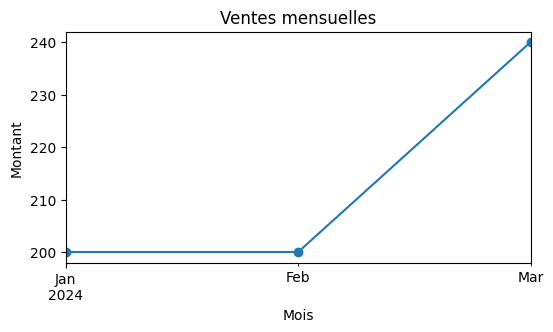

In [6]:
import matplotlib.pyplot as plt

# Une serie de ventes datées
ventes_dates = pd.DataFrame({
    'date': pd.to_datetime(['2024-01-15', '2024-01-28', '2024-02-10', '2024-03-05',
                            '2024-03-21']),
    'montant': [120, 80, 200, 150, 90]
})

# L'accesseur .dt : extraire l'annee
ventes_dates['annee'] = ventes_dates['date'].dt.year
print('=== .dt.year ===')
print(ventes_dates[['date', 'annee', 'montant']])

# Agregation mensuelle : resample apres mise en index temporel
par_mois = ventes_dates.set_index('date')['montant'].resample('ME').sum()
print('\n=== Ventes mensuelles (resample ME) ===')
print(par_mois)

# Figure
plt.figure(figsize=(6, 3))
par_mois.plot(marker='o', title='Ventes mensuelles')
plt.ylabel('Montant')
plt.xlabel('Mois')
plt.show()


## Lecture d'un fichier réel : `read_csv`

Un `DataFrame` construit à la main ne survit pas au vrai monde : les données arrivent
dans un fichier. `pd.read_csv` est la porte d'entrée, et **deux arguments coincent
toujours** : `sep` (le séparateur n'est pas toujours une virgule — un CSV français peut
utiliser `;`) et `parse_dates` (sans lui, la colonne date reste une chaîne de caractères,
et toute opération temporelle échoue). Ici on **écrit** un fichier pour montrer le
circuit complet, puis on le lit.


In [7]:
import os

# 1. Ecrire un petit CSV (le séparateur est un point-virgule, les dates sont des chaînes)
chemin_csv = os.path.join(os.getcwd(), 'export_ventes_demo.csv')
pd.DataFrame({
    'Date': ['2024-01-15', '2024-02-10', '2024-03-05'],
    'montant': [120, 330, 240]
}).to_csv(chemin_csv, index=False, sep=';')

# 2. Relire avec les bons arguments : sep=';' et parse_dates=['Date']
df_relu = pd.read_csv(chemin_csv, sep=';', parse_dates=['Date'])
print('=== Fichier relu ===')
print(df_relu)
print('\n=== Types apres parse_dates ===')
print(df_relu.dtypes)

# 3. Nettoyer le fichier temporaire (il est regenere a chaque execution)
os.remove(chemin_csv)


=== Fichier relu ===
        Date  montant
0 2024-01-15      120
1 2024-02-10      330
2 2024-03-05      240

=== Types apres parse_dates ===
Date       datetime64[us]
montant             int64
dtype: object


## Exemple guide : Analyse d'un Dataset Étudiants

À vous de pratiquer la création et la manipulation de DataFrames avec Pandas !

### Objectifs
Créez un DataFrame d'étudiants et effectuez des analyses simples.

### Instructions



In [8]:
import pandas as pd

#Exemple guide: Créez un DataFrame avec 5 étudiants
# Colonnes: 'Nom', 'Age', 'Note', 'Filiere'
data = {
    'Nom': [...],      # 5 noms différents
    'Age': [...],      # Âges entre 18 et 25
    'Note': [...],     # Notes entre 0 et 20
    'Filiere': [...]   # Ex: 'Info', 'Maths', 'Physique'
}

df = None  # Créez le DataFrame

#Exemple guide: Affichez les 3 premières lignes
# Indice: utilisez df.head(3)

#Exemple guide: Calculez la moyenne des notes
moyenne_notes = None  # Utilisez df["Note"].mean()

#Exemple guide: Filtrez les étudiants avec Note >= 15
excellents = None  # Utilisez une condition booléenne

#Exemple guide: Groupez par filière et calculez la moyenne des notes
par_filiere = None  # Utilisez df.groupby("Filiere")["Note"].mean()

# Affichage
if df is not None and excellents is not None:
    print(f"Moyenne générale: {moyenne_notes}")
    print(f"Étudiants excellents (>= 15): {len(excellents)}")
    print(f"Moyenne par filière:")
    print(par_filiere)
else:
    print("Exercice à compléter : créez le DataFrame et remplacez les None")


Exercice à compléter : créez le DataFrame et remplacez les None


Mise en pratique : creation de DataFrame.

In [9]:
#Exemple guide : Creez votre propre DataFrame
# Creez un DataFrame avec les informations suivantes :
# - 3 etudiants (Alice, Bob, Charlie)
# - Colonnes : 'Nom', 'Age', 'Note'

#Exemple guide: Creez le dictionnaire de donnees
# Indice: utilisez la meme structure que l'exemple precedent (dictionnaire avec listes)
donnees_exo = {
    'Nom': [...],     # Remplacez ... par les 3 noms
    'Age': [...],     # Remplacez ... par 3 ages
    'Note': [...],    # Remplacez ... par 3 notes
}

#Exemple guide: Creez le DataFrame a partir du dictionnaire
df_etudiants = None  # Remplacez None

# Affichez le DataFrame
print(df_etudiants)

#Exemple guide: Affichez uniquement la colonne 'Note'
# Indice: utilisez la notation df['nom_colonne']
notes = None  # Remplacez None
print(f"\nNotes des etudiants : {notes}")


None

Notes des etudiants : None


### Exercice 1 : Filtrage et tri d'un DataFrame

Le filtrage et le tri sont des opérations fondamentales en analyse de données. Vous allez créer un DataFrame de produits et appliquer des filtres combinés avec un tri pour extraire des informations spécifiques.

**Objectif** : Créer un DataFrame de produits, filtrer les produits par prix et catégorie, puis trier les résultats.

**Indices** :
- Combinez plusieurs conditions avec `&` (ET) ou `|` (OU) en utilisant des parentheses
- Utilisez `df.sort_values(by='colonne', ascending=False)` pour trier par ordre decroissant
- `df.reset_index(drop=True)` pour reinitialiser les indices après filtrage

In [10]:
# Exercice 1 : Filtrage et tri
# Creez un DataFrame de produits et appliquez des filtres combinés

# Etape 1: Creez le DataFrame
produits = pd.DataFrame({
    'Produit': ['Ordinateur', 'Telephone', 'Tablette', 'Casque', 'Souris', 'Clavier'],
    'Categorie': ['Electronique', 'Electronique', 'Electronique', 'Accessoire', 'Accessoire', 'Accessoire'],
    'Prix': [999, 699, 399, 89, 49, 79],
    'Stock': [10, 25, 15, 50, 100, 75]
})

# Etape 2: Filtrez les produits Electronique avec un Prix > 400
# Indice: (produits['Categorie'] == 'Electronique') & (produits['Prix'] > 400)
produits_chers = None  # Remplacez None

# Etape 3: Triez les resultats par prix decroissant
# Indice: produits_chers.sort_values(by='Prix', ascending=False)
produits_tries = None  # Remplacez None

# Affichage
if produits_chers is not None:
    print("Produits Electronique avec Prix > 400 :")
    print(produits_tries)
else:
    print("Exercice 1 a completer : filtrage et tri d'un DataFrame")

Exercice 1 a completer : filtrage et tri d'un DataFrame


### Exercice 2 : Agrégation et groupby

Les opérations d'agregation permettent de synthetiser les données par groupes. Vous allez utiliser les fonctions `groupby()`, `agg()` et les statistiques descriptives pour analyser un jeu de données de ventes.

**Objectif** : Calculer des statistiques par catégorie (somme, moyenne, nombre) sur un DataFrame de ventes.

**Indices** :
- `df.groupby('colonne')` créé un groupe par valeur unique de la colonne
- `df.groupby('cat')['val'].agg(['sum', 'mean', 'count'])` pour plusieurs agregats en une fois
- `df.groupby('cat').describe()` pour un resume statistique complet par groupe

In [11]:
# Exercice 2 : Agregation et groupby
# Analysez des donnees de ventes avec les fonctions d'agregation

# Etape 1: Creez le DataFrame de ventes
ventes = pd.DataFrame({
    'Vendeur': ['Alice', 'Bob', 'Alice', 'Charlie', 'Bob', 'Alice', 'Charlie', 'Bob'],
    'Produit': ['A', 'A', 'B', 'B', 'A', 'C', 'C', 'C'],
    'Montant': [150, 200, 300, 250, 100, 400, 350, 175]
})

# Etape 2: Calculez le montant total par vendeur
# Indice: ventes.groupby('Vendeur')['Montant'].sum()
total_par_vendeur = None  # Remplacez None

# Etape 3: Calculez les statistiques par produit (somme, moyenne, nombre)
# Indice: ventes.groupby('Produit')['Montant'].agg(['sum', 'mean', 'count'])
stats_par_produit = None  # Remplacez None

# Etape 4: Trouvez le vendeur avec le plus grand chiffre d'affaires
# Indice: total_par_vendeur.idxmax()
meilleur_vendeur = None  # Remplacez None

# Affichage
if total_par_vendeur is not None:
    print("Montant total par vendeur :")
    print(total_par_vendeur)
    print(f"\nStatistiques par produit :\n{stats_par_produit}")
    print(f"\nMeilleur vendeur : {meilleur_vendeur}")
else:
    print("Exercice 2 a completer : agregation et groupby")

Exercice 2 a completer : agregation et groupby


### Exercice 3 : Transformation et nettoyage de colonnes

En pratique, les données necessitent souvent des transformations avant analyse : conversion de types, renommage de colonnes, creation de nouvelles colonnes calculees. Vous allez appliquer ces opérations sur un DataFrame d'employes.

**Objectif** : Transformer un DataFrame en ajoutant une colonne calculee, renommant des colonnes et convertissant des types.

**Indices** :
- `df['nouvelle'] = df['col1'] * df['col2']` pour créer une colonne calculee
- `df.rename(columns={'ancien': 'nouveau'})` pour renommer
- `df['col'].astype(float)` ou `pd.to_numeric()` pour convertir des types
- `df.drop(columns=['col'])` pour supprimer une colonne

In [12]:
# Exercice 3 : Transformation et nettoyage de colonnes
# Transformez un DataFrame d'employes

# Etape 1: Creez le DataFrame d'employes
employes = pd.DataFrame({
    'nom': ['Alice', 'Bob', 'Charlie', 'Diana'],
    'salaire_mensuel': ['3000', '2500', '4000', '3500'],  # Type string (a convertir)
    'prime_percent': [10, 5, 15, 8]
})

# Etape 2: Convertissez la colonne salaire_mensuel en float
# Indice: employes['salaire_mensuel'] = employes['salaire_mensuel'].astype(float)

# Etape 3: Calculez le salaire annuel dans une nouvelle colonne 'salaire_annuel'
# Indice: salaire_mensuel * 12
salaire_annuel = None  # Remplacez None

# Etape 4: Calculez la prime en euros (salaire_annuel * prime_percent / 100)
# Indice: creez une colonne 'prime_euros'
prime_euros = None  # Remplacez None

# Etape 5: Renommez la colonne 'prime_percent' en 'prime_pourcentage'
# Indice: employes.rename(columns={'prime_percent': 'prime_pourcentage'})
employes_renomme = None  # Remplacez None

# Affichage
if salaire_annuel is not None:
    print("DataFrame transforme :")
    print(employes_renomme)
else:
    print("Exercice 3 a completer : transformation et nettoyage de colonnes")

Exercice 3 a completer : transformation et nettoyage de colonnes


### Exercice 4 : Joindre et diagnostiquer les valeurs manquantes

Combinez les deux notions de ce notebook : rapprochez deux tables, puis mesurez
l'impact des valeurs manquantes sur le résultat.

**Objectif** : joindre des commandes à leurs clients et diagnostiquer les `NaN` issus
de la jointure.

**Indices** :
- `pd.merge(a, b, on='cle', how='left')` pour garder toutes les commandes
- `resultat.isna().sum()` pour compter les manquants après jointure
- `resultat['col'].fillna(valeur)` si vous voulez imputer


In [13]:
# Exercice 4 : Joindre et diagnostiquer les NaN

# Etape 1: Deux tables a rapprocher sur une cle commune
clients2 = pd.DataFrame({
    'id_client': [1, 2, 3],
    'nom': ['Alice', 'Bob', 'Charles']
})
commandes2 = pd.DataFrame({
    'id_client': [1, 3, 99],
    'total': [300, 120, 450]
})

# Etape 2: Joignez en gardant TOUTES les commandes (how='left')
# Indice: pd.merge(commandes2, clients2, on='id_client', how='left')
resultat_join = None  # Remplacez None

# Etape 3: Diagnostiquez les NaN resultants
# Indice: resultat_join.isna().sum()
nan_par_colonne = None  # Remplacez None

# Etape 4: Comptez les commandes sans client connu
# Indice: resultat_join['nom'].isna().sum()
commandes_sans_client = None  # Remplacez None

# Affichage
if resultat_join is not None:
    print('Resultat de la jointure :')
    print(resultat_join)
    print('\nNaN par colonne :')
    print(nan_par_colonne)
    print(f'\nCommandes sans client connu : {commandes_sans_client}')
else:
    print('Exercice 4 a completer : joindre et diagnostiquer les valeurs manquantes')


Exercice 4 a completer : joindre et diagnostiquer les valeurs manquantes


## Conclusion

Ce notebook a permis d explorer les aspects essentiels de 1.3 analyse de données avec pandas. Les points cles :

- Les concepts fondamentaux ont ete presentes et illustres
- Les exercices proposent une mise en pratique progressive
- Les résultats obtenus permettent de valider la comprehension

**Pour aller plus loin** : approfondir les aspects avances du sujet et explorer les liens avec d autres domaines.

## Références

1. W. McKinney, *Data Structures for Statistical Computing in Python*, Proceedings of the 9th Python in Science Conference (SciPy 2010), pp. 51-56, 2010. Article fondateur de Pandas : structures `Series` et `DataFrame`, conçues pour le calcul statistique sur données étiquetées.
2. W. McKinney, *Python for Data Analysis: Data Wrangling with Pandas, NumPy, and Jupyter*, O'Reilly Media, 3e édition, 2022. Référence livresque canonique sur l'usage pratique de Pandas (`groupby`, indexation, nettoyage).
3. T. Wes McKinney, *pandas: a Foundational Python Library for Data Analysis and Statistics*, 2011. Notes techniques complémentaires sur l'architecture interne de Pandas.